In [7]:
import os
import sys
PROJECT_ROOT = os.path.abspath(".")
CODES_DIR = os.path.join(PROJECT_ROOT, "codes")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
if CODES_DIR not in sys.path:
    sys.path.insert(0, CODES_DIR)


In [ ]:
from model_hmm import HMM_Result_Parallel, recover_params, draw_hmm_structure, get_station_pi
from mdpframework import Environment
from util import ALL_MAP, ACT_MARK
import pandas as pd

In [8]:
env = Environment(exp_dir = 'data/step_level_0420.csv')

In [ ]:
# 运行拟合结果的过程，不需要重复跑
# full_df = HMM_Result_Parallel(env, ALL_MAP, data_type='log', llik_type='norm', 
#                                 RT_colname='Before', n_jobs=-4, n_start=20, verbose=3)

Iterating map intro with 1118 ids.
Iterating map tutorial with 1118 ids.
Iterating map base with 1118 ids.
Iterating map target with 1118 ids.
Iterating map maze with 218 ids.
Iterating map make with 201 ids.
Iterating map break with 217 ids.
Iterating map helper with 482 ids.
共 5590 个 (map, uid) 待拟合，使用 n_jobs=-4


[Parallel(n_jobs=-4)]: Using backend LokyBackend with 29 concurrent workers.
[Parallel(n_jobs=-4)]: Done  70 tasks      | elapsed:   12.3s
[Parallel(n_jobs=-4)]: Done 230 tasks      | elapsed:   47.7s
[Parallel(n_jobs=-4)]: Done 454 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-4)]: Done 742 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-4)]: Done 1094 tasks      | elapsed:  4.6min
[Parallel(n_jobs=-4)]: Done 1510 tasks      | elapsed:  7.3min
[Parallel(n_jobs=-4)]: Done 1990 tasks      | elapsed: 11.9min
[Parallel(n_jobs=-4)]: Done 2534 tasks      | elapsed: 57.3min
[Parallel(n_jobs=-4)]: Done 3142 tasks      | elapsed: 130.9min
[Parallel(n_jobs=-4)]: Done 3814 tasks      | elapsed: 245.3min
[Parallel(n_jobs=-4)]: Done 4550 tasks      | elapsed: 343.8min
[Parallel(n_jobs=-4)]: Done 5350 tasks      | elapsed: 400.6min
[Parallel(n_jobs=-4)]: Done 5590 out of 5590 | elapsed: 426.8min finished


完成: 5590 成功, 0 失败


In [3]:
step = env.em.rebuild_total_df()
sub = recover_params(env, ALL_MAP)

Iterating map intro with 1118 ids.
Iterating map tutorial with 1118 ids.
Iterating map base with 1118 ids.
Iterating map target with 1118 ids.
Iterating map maze with 218 ids.
Iterating map make with 201 ids.
Iterating map break with 217 ids.
Iterating map helper with 482 ids.


In [4]:
mu_par = [col for col in sub.columns if col.startswith('mu_')]
sigma_par = [col for col in sub.columns if col.startswith('sigma_')]
A_par = [col for col in sub.columns if col.startswith('A_')]
pi_par = [col for col in sub.columns if col.startswith('pi_')]
sub[A_par].describe()

,A_00,A_01,A_02,A_03,A_10,A_11,A_12,A_13,A_20,A_21,A_22,A_23,A_30,A_31,A_32,A_33
count,5590.000000,5590.000000,5590.0,5590.000000,5590.000000,5590.000000,5590.0,5590.000000,5590.000000,5590.0,5590.000000,5590.000000,5590.000000,5590.0,5590.000000,5590.000000
mean,0.563332,0.333513,0.0,0.103155,0.467133,0.368519,0.0,0.137873,0.431892,0.0,0.341739,0.178068,0.307606,0.0,0.439917,0.251940
std,0.226119,0.223181,0.0,0.123730,0.282412,0.266510,0.0,0.226679,0.327949,0.0,0.288025,0.249762,0.250253,0.0,0.290276,0.213518
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,0.470229,0.183099,0.0,0.000002,0.295996,0.147814,0.0,0.000000,0.191211,0.0,0.000000,0.000000,0.098450,0.0,0.228450,0.000000
50%,0.610383,0.277244,0.0,0.071972,0.469346,0.384186,0.0,0.067013,0.359287,0.0,0.366676,0.087073,0.296533,0.0,0.364851,0.273908
75%,0.722513,0.418964,0.0,0.142857,0.621108,0.534309,0.0,0.151948,0.637916,0.0,0.569657,0.250455,0.459513,0.0,0.581806,0.415524
max,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,0.0,1.000000,0.918238


# to-do list

- 质量控制：参数分布箱线图，异常被试检测
- 状态语义：每个状态占比，dwell_time（自环概率） 和 进入退出概率
- 平稳分布 pi 和熵率 entropy
- 个体差异和被试分型 (mu, sigma, Aij, 平稳分布)
- 作为指标进行预测 表现，解出率等


In [ ]:
def get_transition_matrix(data, level = None):
    if level is not None:
        data = data[data.Map == level]
    return data[A_par].mean().values.reshape(4, 4)

for mn in ALL_MAP:
    trans_matrix = get_transition_matrix(sub, level=mn)
    draw_hmm_structure(trans_matrix, saving = mn)

In [8]:
get_station_pi(trans_matrix)

array([0.48104725, 0.2577787 , 0.10784607, 0.15332798])

In [ ]:
sub1 = pd.read_csv('data/eposide_level.csv')
sub1.head(2)

,Uid,Map,Win,N_step,N_unit,N_chunk,N_seq,N_subgoal,Total_RT,Mean_RT,...,Median_RT,Mean_PD,Std_PD,Mean_Exe,Mean_Pre,Mean_Post,Mean_Plan,N_state,N_op,U_op
0,0,intro,True,14,5,4,3,2,28541,1902.733333,...,566.0,0.933333,0.798809,0.333333,0.200000,0.199933,0.266733,10,5,"['{}' '{0:[(w,c,16)]}' '{0:[(d,d,4)]}' '{0:[(d..."
1,1,intro,True,5,4,3,2,1,7531,1255.166667,...,733.5,0.833333,0.752773,0.333333,0.166667,0.166667,0.333333,6,4,"['{}' '{0:[(d,d,4)]}' '{0:[(d,d,4)];1:[(d,s,2)..."


In [ ]:
sub2.groupby('Win').Mean_RT.mean() # 失败者长尾效应

Win
False    647.873295
True     573.772623
Name: Mean_RT, dtype: float64

array([[ 1.       , -0.2894656],
       [-0.2894656,  1.       ]])

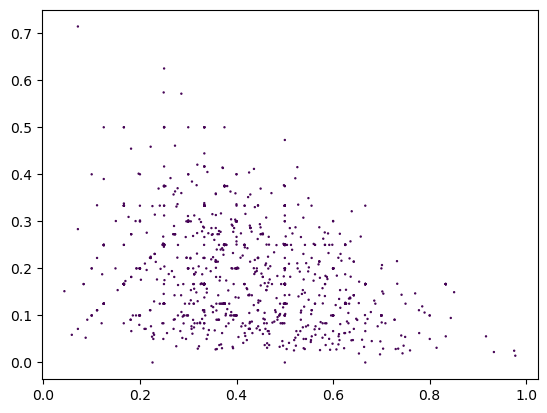

In [78]:
sub2 = sub1[sub1.Map == 'intro']
A, B = 'Mean_Exe', 'Mean_Plan'
plt.scatter(sub2[A], sub2[B], c=sub2['Win'], s=0.5)
np.corrcoef(sub2[A], sub2[B])

In [ ]:
# 1 基于 chain 的反应时间分析

In [136]:
target = env.em.rebuild_total_df('tutorial')
from trans_analyzer import PushChain
chain_row_counts = target.Chain.value_counts()
chain_library = pd.DataFrame({
    'Chain': chain_row_counts.index,
    'Count': chain_row_counts.values,
    'Property_Chain': map(PushChain.property_chain, chain_row_counts.index),
    'Texture_Chain': map(PushChain.texture_chain, chain_row_counts.index),
    'GlobalID_Chain': map(PushChain.globalid_chain, chain_row_counts.index),
    'Complex_Chain': map(PushChain.complex_chain, chain_row_counts.index),
    'Full_Chain': map(PushChain.full_chain, chain_row_counts.index)
}).set_index('Chain')

map_check = {'navigation': 0, 'restart': 2, 'undo': 2}
target.loc[:, 'Complex_Chain',] = target.Chain.map(chain_library['Complex_Chain'])
target.loc[target.Complex_Chain.isna(), 'Complex_Chain'] = 'navigation'
target.loc[:, 'Complex_Chain_idx'] = target.Complex_Chain.map(map_check).fillna(1).astype(int)
target.loc[:, 'Before_Chain'] = target.groupby('Uid').Complex_Chain.shift(1, fill_value='start')
target.loc[:, 'Before_Chain_idx'] = target.Before_Chain.map(map_check).fillna(1).astype(int)


In [137]:
# 分被试 summary chain_idx
x1, x2 = 'Complex_Chain_idx', 'Before_Chain_idx'
chain_rt_sum_pre = target.groupby(['Uid', x1]).pred_DD.mean().groupby(x1).agg(['mean', 'median', 'count'])
chain_rt_sum_post = target.groupby(['Uid', x2]).pred_DD.mean().groupby(x2).agg(['mean', 'median', 'count'])
# chain_rt_sum_pre = target.groupby(x1).pred_DD.agg(['mean', 'median', 'count'])
# chain_rt_sum_post = target.groupby(x2).pred_DD.agg(['mean', 'median', 'count'])
chain_rt_sum = chain_rt_sum_pre.join(chain_rt_sum_post, lsuffix='_pre', rsuffix='_post')
chain_rt_sum[chain_rt_sum['count_post'] > 1].sort_values('mean_pre', ascending=False)

,mean_pre,median_pre,count_pre,mean_post,median_post,count_post
Complex_Chain_idx,,,,,,
2,1.808136,2.000000,631,1.577866,1.881000,631
0,0.879119,0.868467,1118,0.601425,0.598333,1118
1,0.628626,0.634798,1118,1.041948,1.006500,1118


In [139]:

# 分被试 summary chain_raw
x1, x2 = 'Complex_Chain', 'Before_Chain'
chain_rt_sum_pre = target.groupby(['Uid', x1]).pred_DD.mean().groupby(x1).agg(['mean', 'median', 'count'])
chain_rt_sum_post = target.groupby(['Uid', x2]).pred_DD.mean().groupby(x2).agg(['mean', 'median', 'count'])
# chain_rt_sum_pre = target.groupby(x1).pred_DD.agg(['mean', 'median', 'count'])
# chain_rt_sum_post = target.groupby(x2).pred_DD.agg(['mean', 'median', 'count'])

chain_rt_sum = chain_rt_sum_pre.join(chain_rt_sum_post, lsuffix='_pre', rsuffix='_post')
chain_rt_sum[chain_rt_sum['count_pre'] > 100].sort_values('count_pre', ascending=False)

,mean_pre,median_pre,count_pre,mean_post,median_post,count_post
Complex_Chain,,,,,,
navigation,0.879119,0.868467,1118,0.601425,0.598333,1118.0
"(((p, 4),),)",0.649304,0.666667,1099,0.797358,0.800800,1099.0
"(((d, 2),),)",0.519714,0.104000,943,NaN,NaN,NaN
"(((s, 8),),)",0.651540,0.610667,560,1.808366,2.000000,560.0
restart,1.797551,2.000000,539,1.559589,1.719000,539.0
"(((p, 4),), ((2, 32),))",0.591682,0.029000,256,1.736068,2.000000,256.0
"(((p, 4),), ((5, 32),))",0.664222,0.542500,210,1.142925,1.000000,210.0
"(((p, 4),), ((d, 2),))",0.693063,1.000000,160,0.984875,1.000000,160.0
"(((d, 2), (p, 4)),)",0.884159,1.000000,157,NaN,NaN,NaN
